In [1]:
# ==========================================
# Lesson 21 - Feature Engineering
# ==========================================

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

ee.Initialize(project="oc-flux")

Map = geemap.Map()

# Study Area (Yamuna River)
point = ee.Geometry.Point([77.2090, 28.6139])

collection = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(point)
    .filterDate("2023-01-01", "2023-12-31")
)

image = collection.median()

Map.centerObject(point, 10)

Map

Map(center=[28.613900000000005, 77.209], controls=(WidgetControl(options=['position', 'transparent_bg'], posit…

In [ ]:
Feature Importance in Python

In [2]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Example Features
X = np.array([
    [0.10,0.15,0.20],
    [0.15,0.18,0.25],
    [0.20,0.22,0.30],
    [0.25,0.28,0.35],
    [0.30,0.35,0.40]
])

# Target
y = np.array([2,3,5,7,9])

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X,y)

print(model.feature_importances_)

[0.35829418 0.35889897 0.28280685]


In [ ]:
Making Feature Importance Easier to Read

In [3]:
feature_names = ["Blue","Green","Red"]

importance = model.feature_importances_

for name,value in zip(feature_names,importance):
    print(f"{name}: {value:.3f}")

Blue: 0.358
Green: 0.359
Red: 0.283


In [ ]:
Visualizing Feature Importance

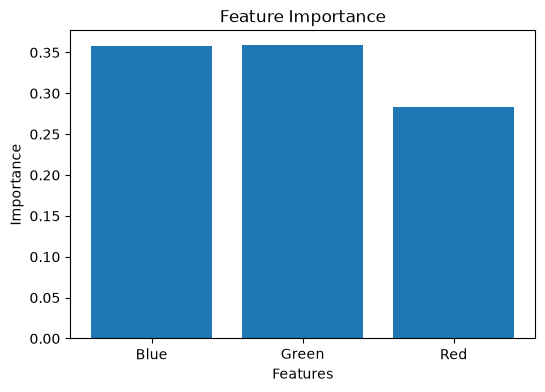

In [4]:
plt.figure(figsize=(6,4))

plt.bar(
    feature_names,
    importance
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

In [ ]:
Building a Feature Stack in Earth Engine
You should see the original Landsat bands plus the newly added indices.

In [5]:
ndwi = image.normalizedDifference(
    ["SR_B3","SR_B5"]
).rename("NDWI")

mndwi = image.normalizedDifference(
    ["SR_B3","SR_B6"]
).rename("MNDWI")

feature_stack = image.addBands(
    [ndwi,mndwi]
)

print(
    feature_stack.bandNames().getInfo()
)

['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDWI', 'MNDWI']


In [ ]:
Visualizing NDWI
Notice that NDWI is now available as another feature for the model.

In [6]:
Map.addLayer(
    ndwi,
    {
        "min":-1,
        "max":1,
        "palette":["brown","white","blue"]
    },
    "NDWI"
)

Map

Map(bottom=109612.0, center=[28.613900000000005, 77.209], controls=(WidgetControl(options=['position', 'transp…